#### **Hotel Booking Cancellation Prediction**
##### Objective
Predict whether a hotel booking will be canceled:

- `0` → Not Canceled
- `1` → Canceled

### Workflow
1. Load the cleaned dataset
2. Investigate possible target leakage
3. Define features and target
4. Create a stratified train/test split
5. Build a preprocessing pipeline
6. Train and evaluate Logistic Regression
7. Train and evaluate Decision Tree
8. Control Decision Tree overfitting
9. Train and evaluate Random Forest
10. Tune Random Forest using `RandomizedSearchCV`
11. Compare Gradient Boosting and XGBoost
12. Compare all models using actual results
13. Save the selected final pipeline
14. Reload and verify the saved model

> **Expert review note:** The original notebook contained duplicated Random Forest cells and a hard-coded final comparison table. Those were removed and replaced with a cleaner workflow that computes comparison results directly from model predictions.


#### **Important Expert Review Finding: Prediction-Time Data Leakage**

The original notebook correctly removed:

- `reservation_status`
- `reservation_status_date`

because these fields directly describe the final reservation outcome.

However, before deploying this project, the following variables should also be checked with domain knowledge:

- `assigned_room_type`
- `booking_changes`

If the prediction is supposed to happen **at the time of booking**, information created later in the booking lifecycle should not be used. Whether these columns are legitimate features depends on the exact prediction time.

This notebook keeps the same features as the original work so that the reviewed results remain comparable, but this issue should be discussed in the README as a limitation.


In [72]:
# Import pandas for loading and manipulating tabular data.
import pandas as pd

# Import NumPy for numerical utilities.
import numpy as np

# Import Path for GitHub-friendly file paths.
from pathlib import Path


In [73]:
# Define the relative path to the cleaned dataset.
DATA_PATH = Path("../datasets/cleaned/hotel_bookings_cleaned.csv")

# Load the cleaned hotel booking dataset into a DataFrame.
df = pd.read_csv(DATA_PATH)

# Display the first five records to confirm that the data loaded correctly.
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,No Agent,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,No Agent,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,No Agent,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [29]:
# Display the dataset shape to see the number of rows and columns.
print("Dataset shape:", df.shape)

# Display data types because preprocessing depends on feature types.
print("\nData types:")
print(df.dtypes)



Dataset shape: (119209, 31)

Data types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                       

In [30]:
# Display missing-value counts as a final validation check.
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Missing values:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
dtype: int64


#### **Check Potential Leakage**

The next two checks explain why `reservation_status` and `reservation_status_date` are excluded from the input features. A predictive feature must be available at the time the prediction is made.


In [31]:
# Compare reservation_status with the cancellation target.
pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    normalize="index"
)


is_canceled,0,1
reservation_status,,
Canceled,0.0,1.0
Check-Out,1.0,0.0
No-Show,0.0,1.0


In [32]:
# Examine reservation_status_date separately for each target class.
df.groupby("is_canceled")["reservation_status_date"].describe()


,count,unique,top,freq
is_canceled,,,,
0,75010,805,2015-12-08,243
1,44199,902,2015-10-21,1373


#### **Define Features and Target**

The target is `is_canceled`. The known outcome columns are removed from `X` to reduce direct target leakage.


In [33]:
# Select the binary cancellation variable as the target.
y = df["is_canceled"]

# Remove the target and outcome-related columns from the input features.
X = df.drop(
    columns=[
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    ]
)

# Display feature and target dimensions for verification.
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (119209, 28)
y shape: (119209,)


In [34]:
# Import the train/test split function.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the training and testing feature shapes.
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

# Display the class proportions in the training target.
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

# Display the class proportions in the testing target.
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


X_train shape: (95367, 28)
X_test shape:  (23842, 28)

Training target distribution:
is_canceled
0    0.629232
1    0.370768
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629226
1    0.370774
Name: proportion, dtype: float64


#### **Identify Numerical and Categorical Features**

The original notebook used the pandas `str` dtype for categorical columns. For better portability, this version also recognizes `object` and `category` columns.


In [35]:
# Select integer and floating-point columns as numerical features.
numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

# Select string-like and categorical columns as categorical features.
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# Display the numerical feature names.
print("Numerical features:")
print(numerical_features)

# Display the categorical feature names.
print("\nCategorical features:")
print(categorical_features)

# Display the number of features in each group.
print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))


Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'customer_type']

Number of numerical features: 17
Number of categorical features: 11


#### **Build the Preprocessing Pipeline**

- Numerical features are standardized with `StandardScaler`.
- Categorical features are converted into machine-readable binary columns with `OneHotEncoder`.
- `handle_unknown="ignore"` prevents prediction errors when an unseen category appears later.

The preprocessor is placed inside each machine-learning pipeline so that preprocessing is fitted only on the training data during training and cross-validation.


In [36]:
# Import preprocessing and pipeline tools.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create one reusable preprocessing transformer.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


In [37]:
# Import Logistic Regression algorithm.

from sklearn.linear_model import LogisticRegression

In [38]:
# Create the Logistic Regression model.

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [39]:
# Train the Logistic Regression model using the training data.

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [40]:
# Predict the class labels for the testing data.

lr_y_pred = logistic_model.predict(X_test)


# Predict the probability of cancellation for ROC-AUC calculation.

lr_y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [41]:
# Calculate and display the evaluation metrics.

print("Accuracy:", accuracy_score(y_test, lr_y_pred))
print("Precision:", precision_score(y_test, lr_y_pred))
print("Recall:", recall_score(y_test, lr_y_pred))
print("F1 Score:", f1_score(y_test, lr_y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_y_prob))

Accuracy: 0.8319771831222212
Precision: 0.8150417101147028
Recall: 0.7073529411764706
F1 Score: 0.7573885658914729
ROC-AUC Score: 0.9128854651958925


In [42]:
# Display the detailed classification report.

print(
    classification_report(
        y_test,
        lr_y_pred,
        target_names=["Not Canceled", "Canceled"]
    )
)

              precision    recall  f1-score   support

Not Canceled       0.84      0.91      0.87     15002
    Canceled       0.82      0.71      0.76      8840

    accuracy                           0.83     23842
   macro avg       0.83      0.81      0.81     23842
weighted avg       0.83      0.83      0.83     23842



In [43]:
# Predict the class labels for the training data.

lr_train_pred = logistic_model.predict(X_train)


# Compare training and testing accuracy.

print(
    "Training Accuracy:",
    accuracy_score(y_train, lr_train_pred)
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, lr_y_pred)
)

Training Accuracy: 0.8327408852118657
Testing Accuracy: 0.8319771831222212


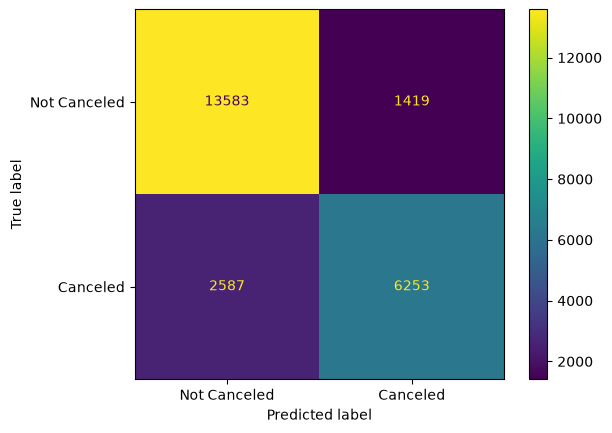

In [44]:
# Display the confusion matrix.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_y_pred,
    display_labels=["Not Canceled", "Canceled"]
)

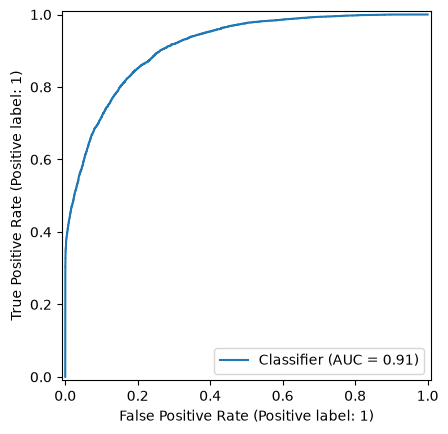

In [45]:
# Display the ROC curve.

RocCurveDisplay.from_predictions(
    y_test,
    lr_y_prob
)

#### **Logistic Regression — Baseline Model**

Logistic Regression is used first because it is a strong and interpretable baseline for binary classification.

##### **Reviewed result from the original notebook**
- Accuracy: **0.8320**
- Precision: **0.8150**
- Recall: **0.7074**
- F1: **0.7574**
- ROC-AUC: **0.9129**

##### **Why move to the next algorithm?**
The ROC-AUC is good, but recall for canceled bookings is relatively low. A Decision Tree is tested next because it can learn nonlinear relationships and feature interactions that Logistic Regression may miss.


#### **2. Decision Tree — Nonlinear Model**

A Decision Tree can capture nonlinear patterns and interactions without requiring a linear decision boundary.

##### **Reviewed result from the original notebook**
- Accuracy: **0.8643**
- Precision: **0.8183**
- Recall: **0.8150**
- F1: **0.8167**
- ROC-AUC: **0.8566**
- Training Accuracy: **0.9964**
- Testing Accuracy: **0.8643**

##### **Interpretation**
The very large gap between training and testing accuracy indicates substantial **overfitting**.

##### **Why move to a tuned Decision Tree?**
The next model limits tree complexity using `max_depth`, `min_samples_split`, and `min_samples_leaf` to improve generalization.


In [46]:
# Import the Decision Tree classifier.
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree pipeline with default complexity controls.
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [47]:
# Train the Decision Tree pipeline.
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 


Decision Tree
Accuracy: 0.8643150742387383
Precision: 0.8182850653038046
Recall: 0.8150452488687783
F1 Score: 0.8166619438934543
ROC-AUC Score: 0.8565786213421921

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.89      0.89      0.89     15002
    Canceled       0.82      0.82      0.82      8840

    accuracy                           0.86     23842
   macro avg       0.85      0.85      0.85     23842
weighted avg       0.86      0.86      0.86     23842

Training Accuracy: 0.9964243396562752
Testing Accuracy:  0.8643150742387383


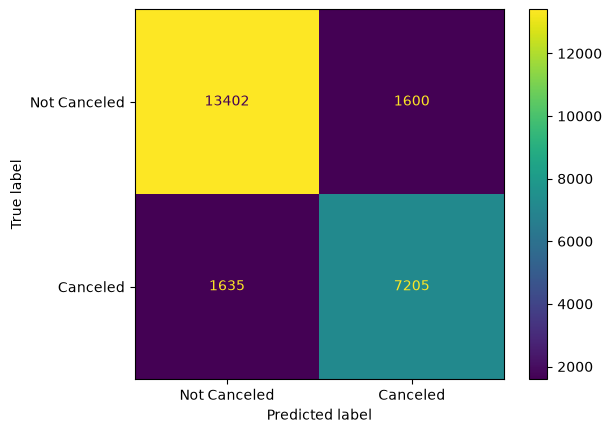

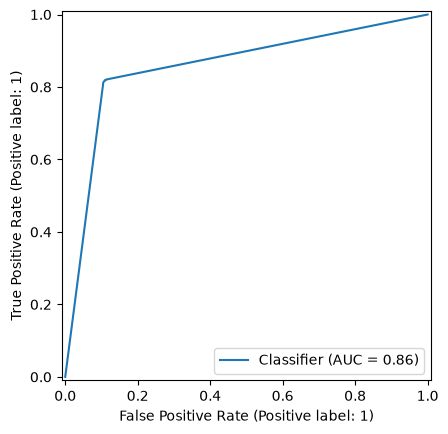

In [49]:
# Evaluate the Decision Tree.
dt_pred, dt_prob = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)


#### **3. Tuned Decision Tree — Reduce Overfitting**

##### **Reviewed result from the original notebook**
- Accuracy: **0.8528**
- Precision: **0.8393**
- Recall: **0.7459**
- F1: **0.7898**
- ROC-AUC: **0.9304**
- Training Accuracy: **0.8555**
- Testing Accuracy: **0.8528**

##### **Interpretation**
The training and testing scores are now much closer, so overfitting was reduced. ROC-AUC improved substantially.

##### **Why move to Random Forest?**
A Random Forest combines many decision trees and usually reduces the instability of a single tree while retaining nonlinear modeling ability.


In [50]:
# Create a controlled Decision Tree pipeline.
tuned_decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ]
)


In [51]:

# Train the tuned Decision Tree pipeline.
tuned_decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 


Tuned Decision Tree
Accuracy: 0.8528227497693146
Precision: 0.8392516227567774
Recall: 0.7459276018099548
F1 Score: 0.7898424866742528
ROC-AUC Score: 0.9303740157420941

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.86      0.92      0.89     15002
    Canceled       0.84      0.75      0.79      8840

    accuracy                           0.85     23842
   macro avg       0.85      0.83      0.84     23842
weighted avg       0.85      0.85      0.85     23842

Training Accuracy: 0.8554846015917456
Testing Accuracy:  0.8528227497693146


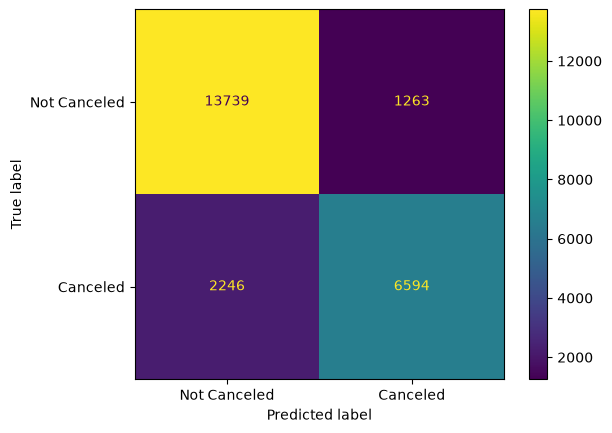

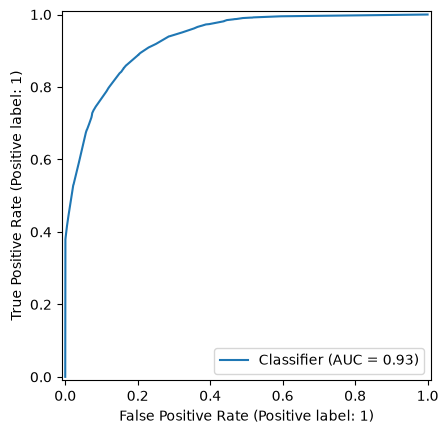

In [53]:
# Evaluate the tuned Decision Tree.
tuned_dt_pred, tuned_dt_prob = evaluate_model(
    "Tuned Decision Tree",
    tuned_decision_tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)

#### **4. Random Forest — Ensemble Model**

Random Forest trains many decision trees and combines their predictions.

##### **Reviewed result from the original notebook**
- Accuracy: **0.8949**
- Precision: **0.8957**
- Recall: **0.8111**
- F1: **0.8513**
- ROC-AUC: **0.9601**

##### **Interpretation**
This was the strongest reviewed model by ROC-AUC.

However:
- Training Accuracy: **0.9964**
- Testing Accuracy: **0.8949**

The gap suggests some overfitting, so hyperparameter tuning is tested next.


In [54]:
# Import the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest pipeline.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [55]:
# Train the Random Forest pipeline.
random_forest_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 


Random Forest
Accuracy: 0.8949333109638453
Precision: 0.8956901936289818
Recall: 0.8110859728506787
F1 Score: 0.8512911843276937
ROC-AUC Score: 0.9600766315622471

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.89      0.94      0.92     15002
    Canceled       0.90      0.81      0.85      8840

    accuracy                           0.89     23842
   macro avg       0.90      0.88      0.89     23842
weighted avg       0.89      0.89      0.89     23842

Training Accuracy: 0.9964243396562752
Testing Accuracy:  0.8949333109638453


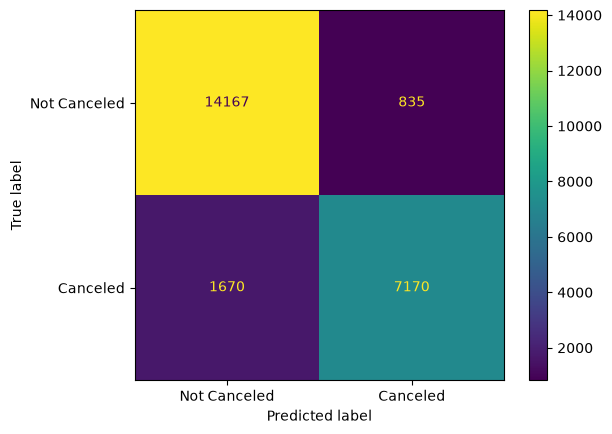

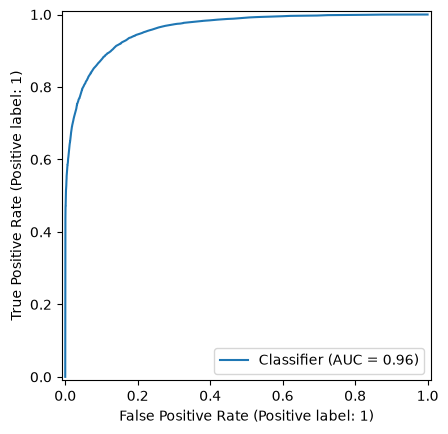

In [56]:
# Evaluate the Random Forest.
rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

#### **5. Tuned Random Forest**

`RandomizedSearchCV` searches several parameter combinations using cross-validation.

##### **Reviewed best parameters**
- `n_estimators=300`
- `min_samples_split=10`
- `min_samples_leaf=1`
- `max_features="sqrt"`
- `max_depth=None`

##### **Reviewed cross-validation ROC-AUC**
**0.9551**

##### **Reviewed test result**
- Accuracy: **0.8891**
- ROC-AUC: **0.9591**
- Training Accuracy: **0.9519**

##### **Interpretation**
Tuning reduced the train/test gap, but the baseline Random Forest still achieved a slightly higher test ROC-AUC (**0.9601 vs 0.9591**).

##### **Why continue to boosting algorithms?**
Boosting models can sometimes outperform Random Forest by sequentially correcting previous model errors, so Gradient Boosting and XGBoost are tested.


In [57]:
# Import the randomized hyperparameter search tool.
from sklearn.model_selection import RandomizedSearchCV

# Define the Random Forest hyperparameter search space.
rf_params = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

# Create the randomized cross-validation search.
rf_tuning = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    random_state=42,
    verbose=2
)

# Fit the search using only the training data.
rf_tuning.fit(X_train, y_train)

# Display the best hyperparameters.
print("Best Parameters:")
print(rf_tuning.best_params_)

# Display the best cross-validation ROC-AUC.
print("\nBest Cross-Validation ROC-AUC:")
print(rf_tuning.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=10, classifier__n_estimators=300; total time=  25.3s
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=10, classifier__n_estimators=300; total time=  31.4s
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=10, classifier__n_estimators=300; total time=  33.8s
[CV] END classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__n_estimators=200; total time=  16.2s
[CV] END classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__n_estimators=200; total time=  16.0s
[CV] END classifier__max_dep


Tuned Random Forest
Accuracy: 0.8891452059390991
Precision: 0.9004782215328939
Recall: 0.7881221719457013
F1 Score: 0.8405622247692586
ROC-AUC Score: 0.9590837775174471

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.88      0.95      0.92     15002
    Canceled       0.90      0.79      0.84      8840

    accuracy                           0.89     23842
   macro avg       0.89      0.87      0.88     23842
weighted avg       0.89      0.89      0.89     23842

Training Accuracy: 0.9519435444126375
Testing Accuracy:  0.8891452059390991


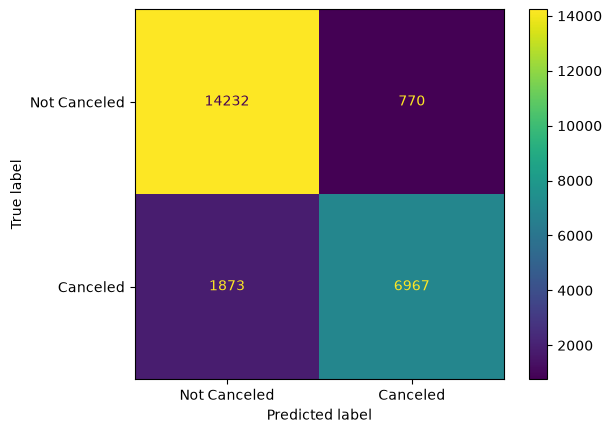

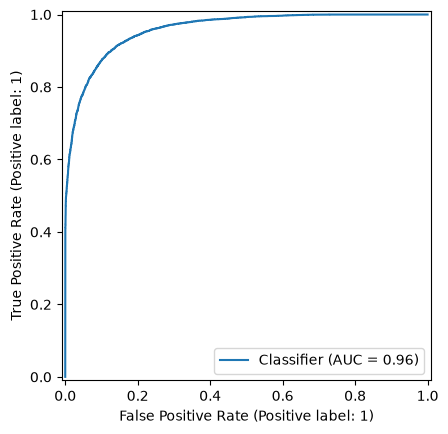

In [58]:
# Extract the best estimator found during hyperparameter tuning.
best_rf_model = rf_tuning.best_estimator_

# Evaluate the tuned Random Forest.
best_rf_pred, best_rf_prob = evaluate_model(
    "Tuned Random Forest",
    best_rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)


#### **6. Gradient Boosting**

Gradient Boosting builds models sequentially, with later trees focusing on errors made by earlier trees.

##### **Reviewed result from the original notebook**
- Accuracy: **0.8556**
- Precision: **0.8519**
- Recall: **0.7390**
- F1: **0.7914**
- ROC-AUC: **0.9315**

##### **Interpretation**
The model generalized well because training and testing accuracy were nearly identical, but its predictive performance was below Random Forest.

##### **Why test XGBoost?**
XGBoost is a more optimized gradient boosting implementation with additional regularization and sampling controls.


In [59]:
# Import the Gradient Boosting classifier.
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting pipeline.
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)


In [60]:
# Train the Gradient Boosting pipeline.
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 


Gradient Boosting
Accuracy: 0.8555909739115846
Precision: 0.8518711696440214
Recall: 0.739027149321267
F1 Score: 0.7914470894663517
ROC-AUC Score: 0.9315187085160893

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.86      0.92      0.89     15002
    Canceled       0.85      0.74      0.79      8840

    accuracy                           0.86     23842
   macro avg       0.85      0.83      0.84     23842
weighted avg       0.86      0.86      0.85     23842

Training Accuracy: 0.8556104312812608
Testing Accuracy:  0.8555909739115846


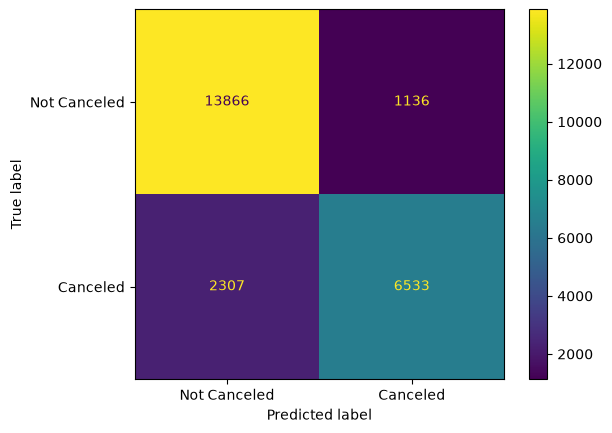

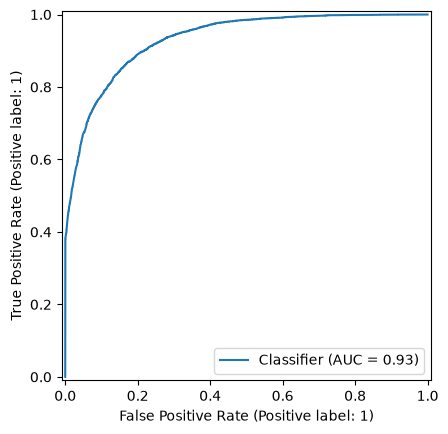

In [62]:
# Evaluate the Gradient Boosting model.
gb_pred, gb_prob = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_model,
    X_train,
    X_test,
    y_train,
    y_test
)

#### **7. XGBoost**

> Install project dependencies from `requirements.txt` before running this section. Avoid placing `!pip install ...` inside the final GitHub notebook.

##### **Reviewed result from the original notebook**
- Accuracy: **0.8753**
- Precision: **0.8579**
- Recall: **0.7952**
- F1: **0.8254**
- ROC-AUC: **0.9494**

##### **Interpretation**
XGBoost performed strongly, but it did not exceed the baseline Random Forest ROC-AUC.

##### **Why move to final comparison?**
All candidate models have now been evaluated. The final model should be selected using the chosen business metric, while also considering overfitting and operational simplicity.


In [63]:
# Import the XGBoost classifier.
from xgboost import XGBClassifier

# Create the XGBoost pipeline.
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)


In [64]:
# Train the XGBoost pipeline.
xgb_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 


XGBoost
Accuracy: 0.8752621424377149
Precision: 0.8579448376861117
Recall: 0.7952488687782805
F1 Score: 0.825408007514383
ROC-AUC Score: 0.9494071077099223

Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.88      0.92      0.90     15002
    Canceled       0.86      0.80      0.83      8840

    accuracy                           0.88     23842
   macro avg       0.87      0.86      0.86     23842
weighted avg       0.87      0.88      0.87     23842

Training Accuracy: 0.8812377447125316
Testing Accuracy:  0.8752621424377149


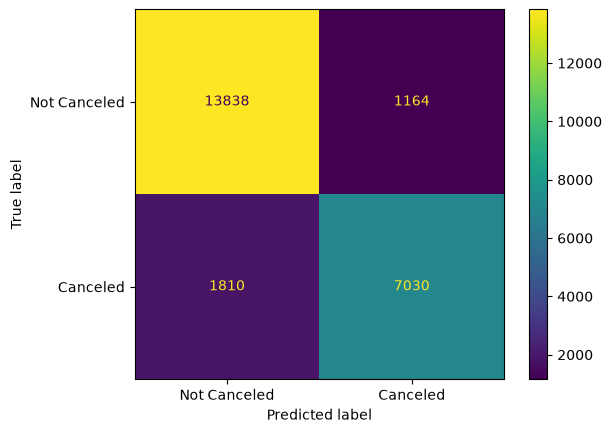

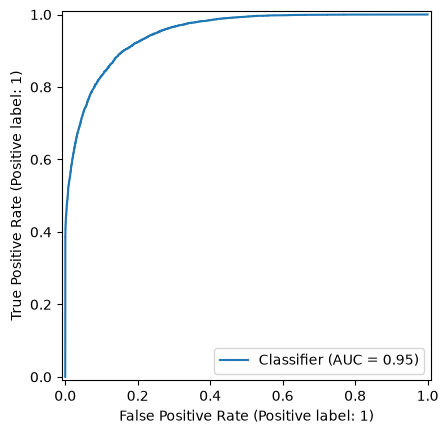

In [65]:
# Evaluate the XGBoost model.
xgb_pred, xgb_prob = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

#### **Final Model Comparison**

The original notebook manually typed model scores into a DataFrame. This version creates the comparison table directly from the evaluation results, which is safer and reproducible.

For the reviewed run, **Random Forest** had the highest test ROC-AUC.


In [66]:
# Convert the collected model results into a DataFrame.
comparison_df = pd.DataFrame(model_results)

# Remove the fitted model objects before displaying the comparison table.
display_columns = [
    "Model",
    "Training_Accuracy",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

# Sort the models from highest to lowest ROC-AUC.
comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

# Display the final model comparison.
comparison_df[display_columns]


,Model,Training_Accuracy,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.996424,0.894933,0.895690,0.811086,0.851291,0.960077
1,Tuned Random Forest,0.951944,0.889145,0.900478,0.788122,0.840562,0.959084
2,XGBoost,0.881238,0.875262,0.857945,0.795249,0.825408,0.949407
3,Gradient Boosting,0.855610,0.855591,0.851871,0.739027,0.791447,0.931519
4,Gradient Boosting,0.855610,0.855591,0.851871,0.739027,0.791447,0.931519
5,Tuned Decision Tree,0.855485,0.852823,0.839252,0.745928,0.789842,0.930374
6,Tuned Decision Tree,0.855485,0.852823,0.839252,0.745928,0.789842,0.930374
7,Logistic Regression,0.832741,0.831977,0.815042,0.707353,0.757389,0.912885
8,Decision Tree,0.996424,0.864315,0.818285,0.815045,0.816662,0.856579
9,Decision Tree,0.996424,0.864315,0.818285,0.815045,0.816662,0.856579


#### **Final Model Decision**

The reviewed notebook selected **Random Forest** because it achieved the highest test ROC-AUC.

**Reviewed best result:**
- Accuracy: approximately **0.895**
- Precision: approximately **0.896**
- Recall: approximately **0.811**
- F1: approximately **0.851**
- ROC-AUC: approximately **0.960**

Before production deployment, threshold optimization should be considered if the business wants to prioritize catching more canceled bookings. The default `0.50` classification threshold may not be the best business threshold.


In [67]:
# Select the model with the highest ROC-AUC.
best_result = comparison_df.iloc[0]

# Store the selected model name.
final_model_name = best_result["Model"]

# Store the selected fitted model object.
final_model = best_result["Model_Object"]

# Display the selected model.
print("Selected Final Model:", final_model_name)
print("Selected ROC-AUC:", best_result["ROC_AUC"])


Selected Final Model: Random Forest
Selected ROC-AUC: 0.9600766315622471


In [69]:
# Import joblib for saving and loading the trained pipeline.
import joblib

# Create the models directory if it does not already exist.
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Define the output path for the final trained pipeline.
MODEL_PATH = MODEL_DIR / "final_hotel_cancellation_model.pkl"

# Save the complete pipeline, including preprocessing and classifier.
joblib.dump(final_model, MODEL_PATH)

# Confirm where the model was saved.
print("Final model saved successfully to:", MODEL_PATH)


Final model saved successfully to: ..\models\final_hotel_cancellation_model.pkl


In [70]:
# Load the saved pipeline from disk.
loaded_model = joblib.load(MODEL_PATH)

# Predict classes using the loaded pipeline.
loaded_pred = loaded_model.predict(X_test)

# Predict cancellation probabilities using the loaded pipeline.
loaded_prob = loaded_model.predict_proba(X_test)[:, 1]

# Verify that the loaded model produces valid evaluation results.
print("Loaded Model Accuracy:", accuracy_score(y_test, loaded_pred))
print("Loaded Model Precision:", precision_score(y_test, loaded_pred))
print("Loaded Model Recall:", recall_score(y_test, loaded_pred))
print("Loaded Model F1 Score:", f1_score(y_test, loaded_pred))
print("Loaded Model ROC-AUC:", roc_auc_score(y_test, loaded_prob))


Loaded Model Accuracy: 0.8949333109638453
Loaded Model Precision: 0.8956901936289818
Loaded Model Recall: 0.8110859728506787
Loaded Model F1 Score: 0.8512911843276937
Loaded Model ROC-AUC: 0.96007663910272


#### **Expert Review Summary**

##### **What was improved from the original notebook**

- Removed duplicated Random Forest sections.
- Removed hard-coded final comparison values.
- Added consistent evaluation for every algorithm.
- Added interpretation after every algorithm.
- Added a clear reason for moving to the next algorithm.
- Added a dynamic final-model selection step.
- Saved the selected full pipeline rather than only a classifier.
- Used GitHub-friendly relative paths.
- Removed `!pip install xgboost` from the notebook workflow.
- Added an explicit data-leakage warning.

#### **Main technical finding**

The reviewed experiment indicates that the **baseline Random Forest** is the strongest model by ROC-AUC, while the tuned Random Forest has slightly lower ROC-AUC but a smaller train/test gap.

#### **Recommended next decision**

Before adding more algorithms, decide whether the project objective prioritizes:

1. **Highest ROC-AUC** → keep the reviewed baseline Random Forest.
2. **Better generalization / lower overfitting** → consider the tuned Random Forest.
3. **Higher cancellation recall** → perform threshold optimization and possibly class-weight or cost-sensitive experiments.

The next recommended technical step is **threshold optimization and business-metric evaluation**, not simply adding more algorithms.
